In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/v_credit_data_NTC_v51825.csv')
print('Data loaded successfully!')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

Data loaded successfully!


In [2]:
print('\n--- EDA: Exploring Consumer Credit Risk Data ---')

print('\n1. Credit Risk Concept and Calculation:')
print('Credit risk is the possibility of a borrower failing to repay a loan or meet their debt obligations.')
print('This dataset focuses on New-To-Credit (NTC) consumers — young adults with little or no credit history.')
print('Key metrics:')
print('- Probability of Default (PD%): The likelihood that a borrower will default (charge-off).')
print('- Net Credit Loss (NCL%): The total dollar amount the lender is at risk for at time of default.')

print('\n2. Exploring the Credit Data:')
print('\nFirst 5 rows:')
print(df.head())

print('\nDataframe information:')
df.info()

print('\nSummary statistics of numerical features:')
print(df.describe())

print('\nValue counts of categorical features:')
for column in df.select_dtypes(include='object').columns:
    print(f"\nValue counts for column '{column}':")
    print(df[column].value_counts())


--- EDA: Exploring Consumer Credit Risk Data ---

1. Credit Risk Concept and Calculation:
Credit risk is the possibility of a borrower failing to repay a loan or meet their debt obligations.
This dataset focuses on New-To-Credit (NTC) consumers — young adults with little or no credit history.
Key metrics:
- Probability of Default (PD%): The likelihood that a borrower will default (charge-off).
- Net Credit Loss (NCL%): The total dollar amount the lender is at risk for at time of default.

2. Exploring the Credit Data:

First 5 rows:
   No_Hit  Age  Ever_Bankruptcy  Months_Since_Bankruptcy  Ever_Collection  \
0       0   24                0                        0                0   
1       1   21                0                        0                0   
2       0   22                0                        0                0   
3       1   24                0                        0                0   
4       0   20                0                        0                0  


3. Correlation with Target Variable Ever_ChargeOff:
Ever_ChargeOff = 1 means the consumer defaulted on a credit obligation.

Correlation Table with Ever_ChargeOff:
                           Ever_ChargeOff
Ever_ChargeOff                   1.000000
Delinq_90D_12M                   0.570991
Ever_Collection                  0.455716
Delinq_60D_Curr                  0.449349
Age                              0.080267
Counseling_Last_12M              0.038057
Revolving_Util                   0.023024
Auth_User_Only                   0.018411
Delinq_30D_Curr                  0.018076
Unpaid_Collection_Trades         0.017719
Income                           0.014146
Delinq_60D_12M                  -0.000307
Student                         -0.000444
Unpaid_Collection_Balance       -0.005499
Card_Inquiry_12M                -0.007435
Student_Loan_Amt                -0.010763
Card_Open_24M                   -0.017145
Unpaid_CO_84M                   -0.020619
Delinq_30D_3M                   -0.02

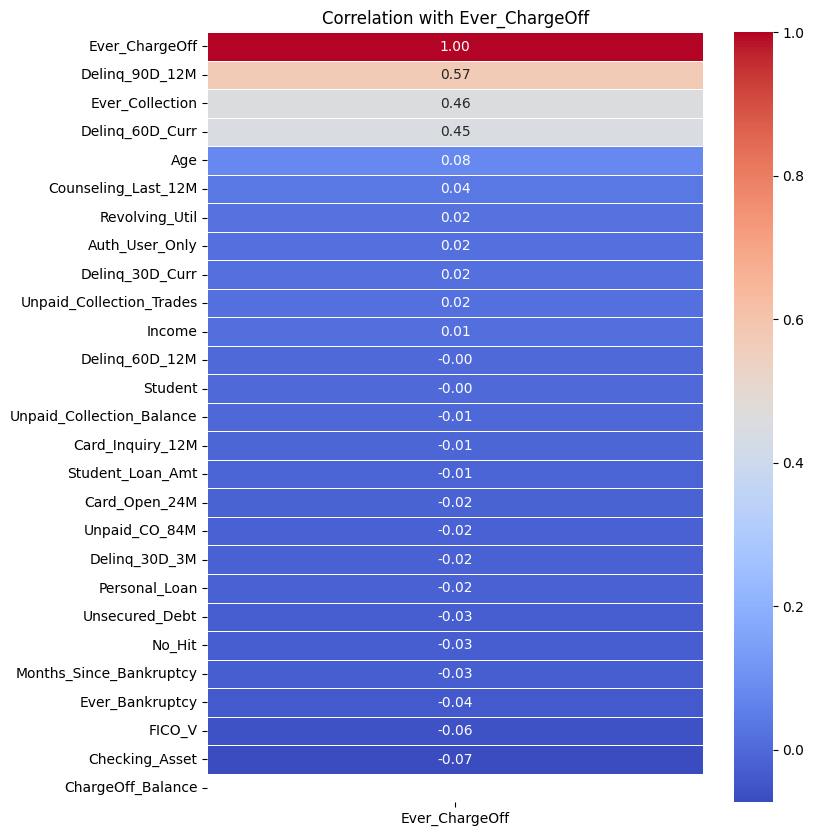

In [3]:
print('\n3. Correlation with Target Variable Ever_ChargeOff:')
print('Ever_ChargeOff = 1 means the consumer defaulted on a credit obligation.')

target_binary = 'Ever_ChargeOff'
numerical_df = df.select_dtypes(include=np.number).copy()

corr_chargeoff = numerical_df.corr()[target_binary].sort_values(ascending=False)

print('\nCorrelation Table with Ever_ChargeOff:')
print(corr_chargeoff.to_frame())

plt.figure(figsize=(8, 10))
sns.heatmap(corr_chargeoff.to_frame(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation with Ever_ChargeOff')
plt.show()


4. Correlation with FICO_V (Credit Score):
FICO_V is missing for No-Hit consumers — they simply have no credit score yet.
We analyze it to understand what drives credit scores among those who have one.

Correlation Table with FICO_V:
                             FICO_V
FICO_V                     1.000000
ChargeOff_Balance          0.198002
Income                     0.055707
Months_Since_Bankruptcy    0.031760
Personal_Loan              0.018060
Ever_Bankruptcy            0.009127
Student                    0.006902
Student_Loan_Amt           0.004977
Revolving_Util            -0.002978
Card_Inquiry_12M          -0.006685
Checking_Asset            -0.008191
Delinq_60D_Curr           -0.009234
Counseling_Last_12M       -0.010478
Unsecured_Debt            -0.012206
Delinq_30D_Curr           -0.014748
Delinq_60D_12M            -0.019221
Unpaid_Collection_Balance -0.028532
Unpaid_CO_84M             -0.030156
Delinq_30D_3M             -0.032939
Delinq_90D_12M            -0.035811
Unpaid_Co

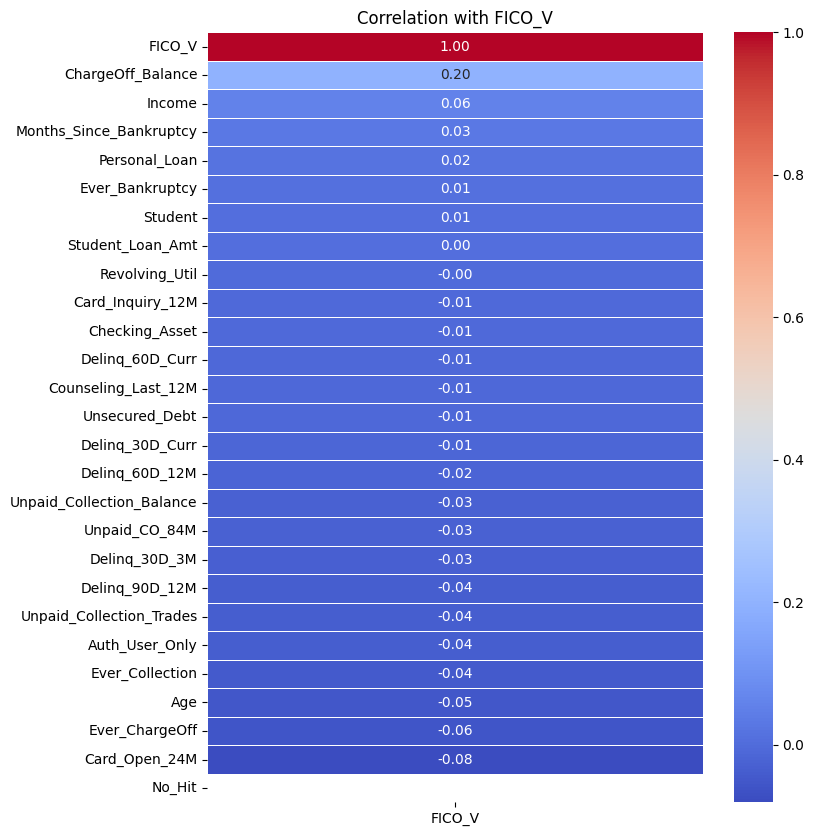

In [4]:
print('\n4. Correlation with FICO_V (Credit Score):')
print('FICO_V is missing for No-Hit consumers — they simply have no credit score yet.')
print('We analyze it to understand what drives credit scores among those who have one.')

corr_fico = numerical_df.corr()['FICO_V'].sort_values(ascending=False)

print('\nCorrelation Table with FICO_V:')
print(corr_fico.to_frame())

plt.figure(figsize=(8, 10))
sns.heatmap(corr_fico.to_frame(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation with FICO_V')
plt.show()

In [5]:
print('\n5. Value Frequency of Binary Columns:')
for column in df.columns:
    if df[column].nunique() == 2:
        print(f"\nValue counts for binary column '{column}':")
        print(df[column].value_counts())

print('\nNote: 41.5% are No-Hit (no credit history). 14.15% ever had a charge-off. 1.45% ever went bankrupt.')


5. Value Frequency of Binary Columns:

Value counts for binary column 'No_Hit':
No_Hit
0    1170
1     830
Name: count, dtype: int64

Value counts for binary column 'Ever_Bankruptcy':
Ever_Bankruptcy
0    1971
1      29
Name: count, dtype: int64

Value counts for binary column 'Ever_Collection':
Ever_Collection
0    1591
1     409
Name: count, dtype: int64

Value counts for binary column 'Counseling_Last_12M':
Counseling_Last_12M
0    1468
1     532
Name: count, dtype: int64

Value counts for binary column 'Unpaid_CO_84M':
Unpaid_CO_84M
0    1533
1     467
Name: count, dtype: int64

Value counts for binary column 'Delinq_90D_12M':
Delinq_90D_12M
0    1531
1     469
Name: count, dtype: int64

Value counts for binary column 'Delinq_60D_12M':
Delinq_60D_12M
0    1540
1     460
Name: count, dtype: int64

Value counts for binary column 'Delinq_60D_Curr':
Delinq_60D_Curr
0    1701
1     299
Name: count, dtype: int64

Value counts for binary column 'Delinq_30D_3M':
Delinq_30D_3M
0    1402
1 


Examining Distributions with Histograms and KDE Plots:


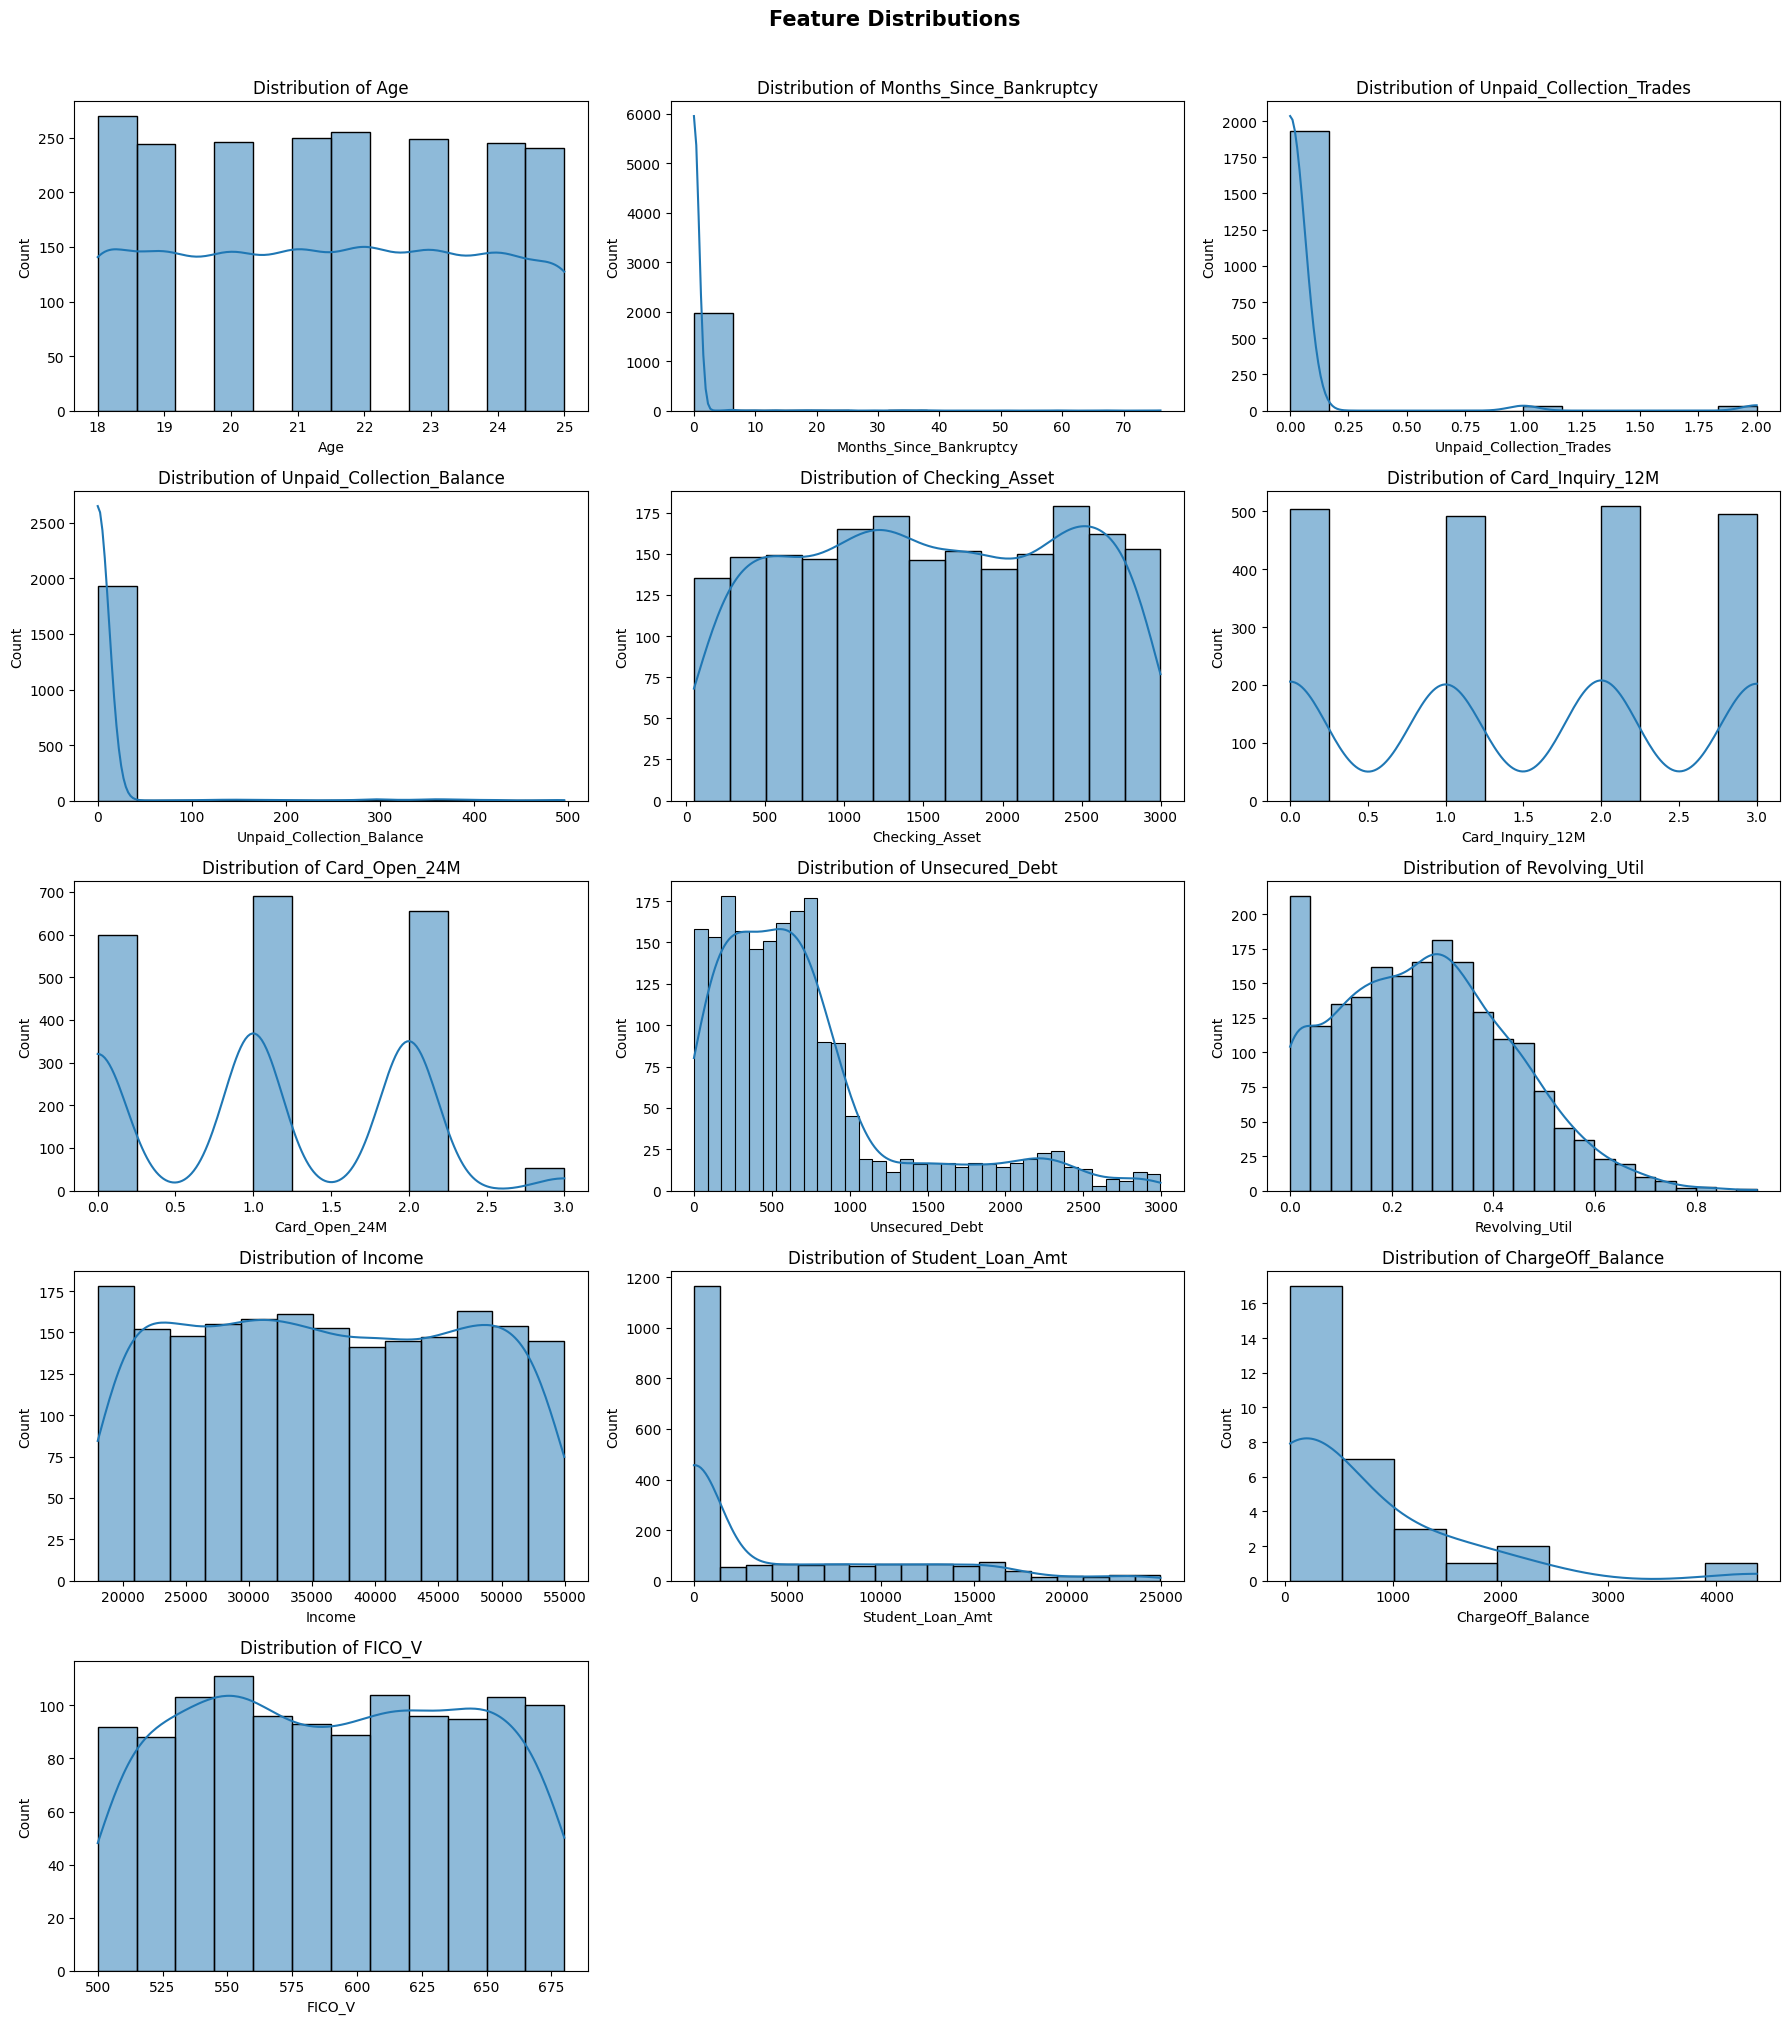


Note: FICO_V and ChargeOff_Balance histograms only show populated values (missing = No-Hit consumers).


In [6]:
print('\nExamining Distributions with Histograms and KDE Plots:')

non_binary_cols = [col for col in numerical_df.columns if numerical_df[col].nunique() > 2]
ncols = 3
nrows = (len(non_binary_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, column in enumerate(non_binary_cols):
    sns.histplot(numerical_df[column], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nNote: FICO_V and ChargeOff_Balance histograms only show populated values (missing = No-Hit consumers).')

In [7]:
print('\n6. Identifying Outliers using IQR Method (Non-Binary Columns):')

for column in numerical_df.columns:
    if numerical_df[column].nunique() > 2:
        Q1 = numerical_df[column].quantile(0.25)
        Q3 = numerical_df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_iqr = numerical_df[column][(numerical_df[column] < lower_bound) | (numerical_df[column] > upper_bound)]
        if not outliers_iqr.empty:
            print(f"\nPotential outliers in '{column}' (IQR method):")
            print(outliers_iqr.head())
        else:
            print(f"\nNo significant outliers found in '{column}' using IQR method.")
    else:
        print(f"\nSkipping IQR outlier detection for binary column '{column}'.")


6. Identifying Outliers using IQR Method (Non-Binary Columns):

Skipping IQR outlier detection for binary column 'No_Hit'.

No significant outliers found in 'Age' using IQR method.

Skipping IQR outlier detection for binary column 'Ever_Bankruptcy'.

Potential outliers in 'Months_Since_Bankruptcy' (IQR method):
144    37
245    23
309    13
323     6
380    13
Name: Months_Since_Bankruptcy, dtype: int64

Skipping IQR outlier detection for binary column 'Ever_Collection'.

Potential outliers in 'Unpaid_Collection_Trades' (IQR method):
41     2
84     1
93     2
118    2
177    2
Name: Unpaid_Collection_Trades, dtype: int64

Potential outliers in 'Unpaid_Collection_Balance' (IQR method):
41     243
84     355
93     166
118    105
177    417
Name: Unpaid_Collection_Balance, dtype: int64

Skipping IQR outlier detection for binary column 'Counseling_Last_12M'.

Skipping IQR outlier detection for binary column 'Unpaid_CO_84M'.

Skipping IQR outlier detection for binary column 'Delinq_90D_1

In [8]:
print('\n7. Removing Outliers (IQR Method, Non-Binary Columns):')
original_row_count = len(df)
rows_removed_per_column = {}
df_cleaned = df.copy()

for column in numerical_df.columns:
    if numerical_df[column].nunique() > 2:
        Q1 = df_cleaned[column].quantile(0.25)
        Q3 = df_cleaned[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_mask = (df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)
        rows_removed = outliers_mask.sum()

        if rows_removed > 0:
            df_cleaned = df_cleaned[~outliers_mask]
            rows_removed_per_column[column] = rows_removed
            print(f"\nRemoved {rows_removed} rows with IQR outliers in column '{column}'.")
        else:
            print(f"\nNo IQR outliers found in column '{column}'.")
    else:
        print(f"\nSkipping outlier removal for binary column '{column}'.")

print(f'\n--- Summary of Rows Removed ---')
print(f'Original number of rows: {original_row_count}')
print(f'Number of rows after outlier removal: {len(df_cleaned)}')
print(f'Total number of rows removed: {original_row_count - len(df_cleaned)}')
print('\nRows removed per column (if any):')
for column, count in rows_removed_per_column.items():
    print(f"  - '{column}': {count}")

print('\nCleaned DataFrame (first 5 rows):')
print(df_cleaned.head())


7. Removing Outliers (IQR Method, Non-Binary Columns):

Skipping outlier removal for binary column 'No_Hit'.

No IQR outliers found in column 'Age'.

Skipping outlier removal for binary column 'Ever_Bankruptcy'.

Removed 29 rows with IQR outliers in column 'Months_Since_Bankruptcy'.

Skipping outlier removal for binary column 'Ever_Collection'.

Removed 66 rows with IQR outliers in column 'Unpaid_Collection_Trades'.

No IQR outliers found in column 'Unpaid_Collection_Balance'.

Skipping outlier removal for binary column 'Counseling_Last_12M'.

Skipping outlier removal for binary column 'Unpaid_CO_84M'.

Skipping outlier removal for binary column 'Delinq_90D_12M'.

Skipping outlier removal for binary column 'Delinq_60D_12M'.

Skipping outlier removal for binary column 'Delinq_60D_Curr'.

Skipping outlier removal for binary column 'Delinq_30D_3M'.

Skipping outlier removal for binary column 'Delinq_30D_Curr'.

No IQR outliers found in column 'Checking_Asset'.

No IQR outliers found in c

In [9]:
print('\n8. Risk with Missing Data in Loan Data:')
print('Missing data is a common problem in real-world datasets.')
print('FICO_V is missing for No-Hit consumers — they have no credit score yet.')
print('ChargeOff_Balance is missing for ~98% of rows — only charged-off accounts have a balance.')

print('\n9. Replacing Missing Credit Data:')
print('For FICO_V: we impute with 999 as a special flag meaning No-Hit (no credit file).')
print('For ChargeOff_Balance: not used as a model feature, so we leave it as-is.')

print('\nMissing values in each column:')
print(df.isnull().sum().sort_values(ascending=False))

print('\n10. Split data into Train, Validation, and Test Data:')
train_df, temp_df = train_test_split(df_cleaned, test_size=0.3, random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f'Training data shape: {train_df.shape}')
print(f'Validation data shape: {val_df.shape}')
print(f'Test data shape: {test_df.shape}')

# Impute FICO missing with 999 (special value = No-Hit)
special_fico_value = 999
train_df['FICO_Imputed'] = train_df['FICO_V'].fillna(special_fico_value).astype(int)
val_df['FICO_Imputed']   = val_df['FICO_V'].fillna(special_fico_value).astype(int)
test_df['FICO_Imputed']  = test_df['FICO_V'].fillna(special_fico_value).astype(int)

print('\nMissing FICO values after imputation:')
print(f'Training:   {train_df["FICO_Imputed"].isnull().sum()}')
print(f'Validation: {val_df["FICO_Imputed"].isnull().sum()}')
print(f'Test:       {test_df["FICO_Imputed"].isnull().sum()}')

print('\nEver_ChargeOff distribution in Train Data:')
print(train_df['Ever_ChargeOff'].value_counts())
print('\nNote: ~14.9% charge-off rate — class imbalance, will be handled in the model.')


8. Risk with Missing Data in Loan Data:
Missing data is a common problem in real-world datasets.
FICO_V is missing for No-Hit consumers — they have no credit score yet.
ChargeOff_Balance is missing for ~98% of rows — only charged-off accounts have a balance.

9. Replacing Missing Credit Data:
For FICO_V: we impute with 999 as a special flag meaning No-Hit (no credit file).
For ChargeOff_Balance: not used as a model feature, so we leave it as-is.

Missing values in each column:
ChargeOff_Balance            1969
FICO_V                        830
No_Hit                          0
Months_Since_Bankruptcy         0
Ever_Collection                 0
Unpaid_Collection_Trades        0
Unpaid_Collection_Balance       0
Counseling_Last_12M             0
Unpaid_CO_84M                   0
Age                             0
Ever_Bankruptcy                 0
Delinq_60D_12M                  0
Delinq_90D_12M                  0
Delinq_60D_Curr                 0
Delinq_30D_3M                   0
Card_In

In [10]:
print('\n11. Feature Engineering — Creating New Columns:')
print('We create DTI (Debt-to-Income) ratio and band variables for easier analysis.')

# DTI = Unsecured Debt / Income
df_cleaned['DTI'] = df_cleaned['Unsecured_Debt'] / df_cleaned['Income']

# Helper function to create bands
def create_bins(series, bins, labels):
    return pd.cut(series, bins=bins, labels=labels, include_lowest=True, right=False)

# FICO Band
fico_bins   = [300, 580, 670, 740, 800, 850]
fico_labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']
df_cleaned['FICO_Band'] = create_bins(df_cleaned['FICO_V'], fico_bins, fico_labels)

# Utilization Band
util_bins   = [0, 0.1, 0.3, 0.6, 1.0, np.inf]
util_labels = ['Very Low (<10%)', 'Low (10-30%)', 'Moderate (30-60%)', 'High (60-100%)', 'Extreme (>100%)']
df_cleaned['Utilization_Band'] = create_bins(df_cleaned['Revolving_Util'], util_bins, util_labels)

# DTI Band
dti_bins   = [0, 0.36, 0.41, 0.43, 0.50, np.inf]
dti_labels = ['Target (<36%)', 'Reasonable (36-41%)', 'Less Favorable (41-43%)', 'High (43-50%)', 'Very High (>50%)']
df_cleaned['DTI_Band'] = create_bins(df_cleaned['DTI'], dti_bins, dti_labels)

# Student Loan Amount Band
loan_bins   = [0, 1000, 5000, 10000, 15000, np.inf]
loan_labels = ['No Debt', 'Low (1K-5K)', 'Moderate (5K-10K)', 'High (10K-15K)', 'Very High (>15K)']
df_cleaned['LoanAmount_Band'] = create_bins(df_cleaned['Student_Loan_Amt'], loan_bins, loan_labels)

# Checking Asset Band
asset_bins   = [0, 500, 1000, 1500, 2000, 2500, np.inf]
asset_labels = ['<500', '501-1000', '1001-1500', '1501-2000', '2001-2500', '>2500']
df_cleaned['Asset_Band'] = create_bins(df_cleaned['Checking_Asset'], asset_bins, asset_labels)

print('\nNew columns created: DTI, FICO_Band, Utilization_Band, DTI_Band, LoanAmount_Band, Asset_Band')
print('\nFICO Band distribution:')
print(df_cleaned['FICO_Band'].value_counts())
print('\nUtilization Band distribution:')
print(df_cleaned['Utilization_Band'].value_counts())
print('\nDTI Band distribution:')
print(df_cleaned['DTI_Band'].value_counts())


11. Feature Engineering — Creating New Columns:
We create DTI (Debt-to-Income) ratio and band variables for easier analysis.

New columns created: DTI, FICO_Band, Utilization_Band, DTI_Band, LoanAmount_Band, Asset_Band

FICO Band distribution:
FICO_Band
Fair           469
Poor           429
Good            69
Very Good        0
Exceptional      0
Name: count, dtype: int64

Utilization Band distribution:
Utilization_Band
Low (10-30%)         678
Moderate (30-60%)    629
Very Low (<10%)      322
High (60-100%)        46
Extreme (>100%)        0
Name: count, dtype: int64

DTI Band distribution:
DTI_Band
Target (<36%)              1675
Reasonable (36-41%)           0
Less Favorable (41-43%)       0
High (43-50%)                 0
Very High (>50%)              0
Name: count, dtype: int64



12. Charge-Off Rate by FICO Band:
           Total  Charged_Off  ChargeOff_Rate  ChargeOff_Rate_%
FICO_Band                                                      
Poor         429           72        0.167832              16.8
Fair         469           65        0.138593              13.9
Good          69            8        0.115942              11.6


/tmp/ipykernel_255/2449693290.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fico_chargeoff.reset_index(), x='FICO_Band', y='ChargeOff_Rate_%', palette='Reds_r')


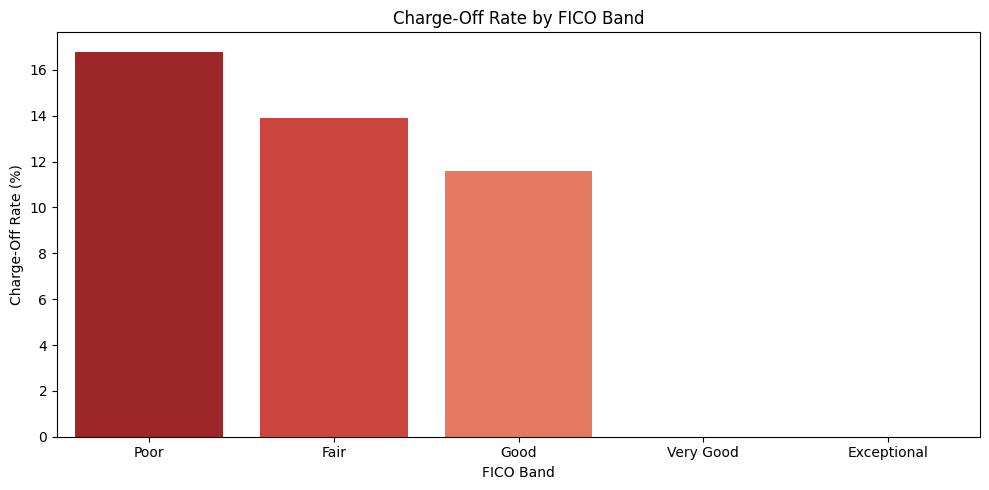

In [11]:
print('\n12. Charge-Off Rate by FICO Band:')

fico_chargeoff = (
    df_cleaned.groupby('FICO_Band', observed=True)['Ever_ChargeOff']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count': 'Total', 'sum': 'Charged_Off', 'mean': 'ChargeOff_Rate'})
)
fico_chargeoff['ChargeOff_Rate_%'] = (fico_chargeoff['ChargeOff_Rate'] * 100).round(1)
print(fico_chargeoff)

plt.figure(figsize=(10, 5))
sns.barplot(data=fico_chargeoff.reset_index(), x='FICO_Band', y='ChargeOff_Rate_%', palette='Reds_r')
plt.title('Charge-Off Rate by FICO Band')
plt.xlabel('FICO Band')
plt.ylabel('Charge-Off Rate (%)')
plt.tight_layout()
plt.show()


13. Charge-Off Rate by Utilization Band:
                   Total  Charged_Off  ChargeOff_Rate  ChargeOff_Rate_%
Utilization_Band                                                       
Very Low (<10%)      322           32        0.099379               9.9
Low (10-30%)         678          106        0.156342              15.6
Moderate (30-60%)    629           94        0.149444              14.9
High (60-100%)        46            6        0.130435              13.0


/tmp/ipykernel_255/3964423329.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=util_chargeoff.reset_index(), x='Utilization_Band', y='ChargeOff_Rate_%', palette='Oranges')


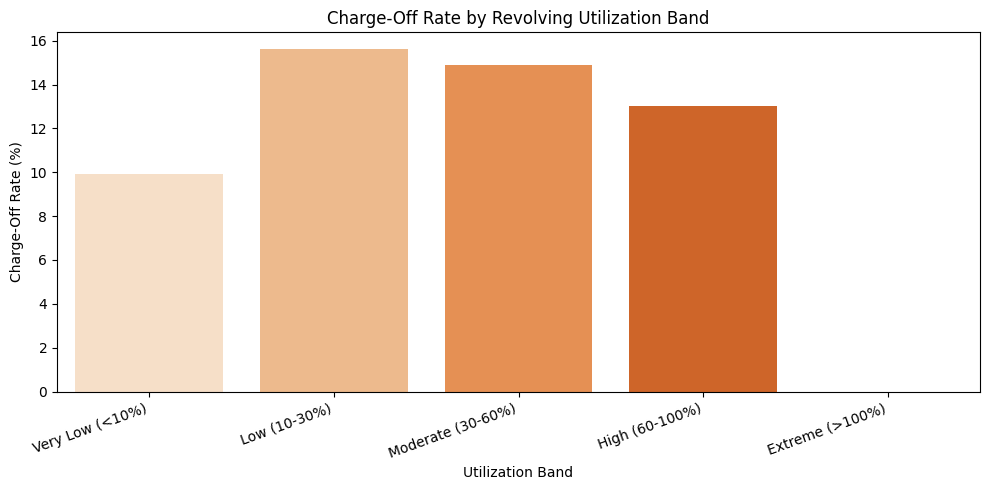

In [12]:
print('\n13. Charge-Off Rate by Utilization Band:')

util_chargeoff = (
    df_cleaned.groupby('Utilization_Band', observed=True)['Ever_ChargeOff']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count': 'Total', 'sum': 'Charged_Off', 'mean': 'ChargeOff_Rate'})
)
util_chargeoff['ChargeOff_Rate_%'] = (util_chargeoff['ChargeOff_Rate'] * 100).round(1)
print(util_chargeoff)

plt.figure(figsize=(10, 5))
sns.barplot(data=util_chargeoff.reset_index(), x='Utilization_Band', y='ChargeOff_Rate_%', palette='Oranges')
plt.title('Charge-Off Rate by Revolving Utilization Band')
plt.xlabel('Utilization Band')
plt.ylabel('Charge-Off Rate (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


=== Step 13: Random Forest — Predict Ever_ChargeOff ===

Features used: ['No_Hit', 'Age', 'Ever_Bankruptcy', 'Months_Since_Bankruptcy', 'Ever_Collection', 'Unpaid_Collection_Trades', 'Unpaid_Collection_Balance', 'Counseling_Last_12M', 'Unpaid_CO_84M', 'Delinq_90D_12M', 'Delinq_60D_12M', 'Delinq_60D_Curr', 'Delinq_30D_3M', 'Delinq_30D_Curr', 'Checking_Asset', 'Card_Inquiry_12M', 'Card_Open_24M', 'Personal_Loan', 'Unsecured_Debt', 'Revolving_Util', 'Income', 'Auth_User_Only', 'Student', 'Student_Loan_Amt', 'DTI', 'FICO_Imputed']

--- Random Forest: Validation Performance ---
[[216   5]
 [ 17  13]]
              precision    recall  f1-score   support

           0      0.927     0.977     0.952       221
           1      0.722     0.433     0.542        30

    accuracy                          0.912       251
   macro avg      0.825     0.705     0.747       251
weighted avg      0.903     0.912     0.903       251

Validation AUC: 0.955


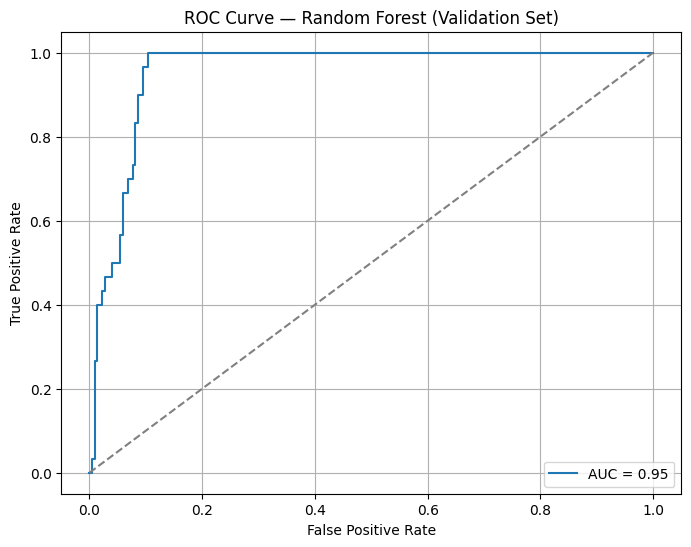


--- Random Forest: Test Set Performance ---
[[207  12]
 [ 17  16]]
              precision    recall  f1-score   support

           0      0.924     0.945     0.935       219
           1      0.571     0.485     0.525        33

    accuracy                          0.885       252
   macro avg      0.748     0.715     0.730       252
weighted avg      0.878     0.885     0.881       252

Test AUC: 0.931


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print('\n=== Step 13: Random Forest — Predict Ever_ChargeOff ===')

# Impute FICO on df_cleaned
df_cleaned['FICO_Imputed'] = df_cleaned['FICO_V'].fillna(999).astype(int)

# Define feature columns
drop_cols    = ['Ever_ChargeOff', 'FICO_V', 'ChargeOff_Balance',
                'FICO_Band', 'Utilization_Band', 'DTI_Band', 'LoanAmount_Band', 'Asset_Band']
feature_cols = [col for col in df_cleaned.columns
                if col not in drop_cols
                and df_cleaned[col].dtype != 'object'
                and df_cleaned[col].dtype.name != 'category']

print('\nFeatures used:', feature_cols)

# Re-split from df_cleaned (now includes DTI and FICO_Imputed)
train_df2, temp_df2 = train_test_split(df_cleaned, test_size=0.3, random_state=42)
val_df2,   test_df2 = train_test_split(temp_df2, test_size=0.5, random_state=42)

X_train = train_df2[feature_cols]
y_train = train_df2['Ever_ChargeOff']
X_val   = val_df2[feature_cols]
y_val   = val_df2['Ever_ChargeOff']
X_test  = test_df2[feature_cols]
y_test  = test_df2['Ever_ChargeOff']

# Train Random Forest
# class_weight='balanced' handles the ~15% charge-off class imbalance
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

# Threshold 0.7 — only flag high-confidence charge-offs
val_probs       = rf_model.predict_proba(X_val)[:, 1]
val_pred_thresh = (val_probs >= 0.7).astype(int)

print('\n--- Random Forest: Validation Performance ---')
print(confusion_matrix(y_val, val_pred_thresh))
print(classification_report(y_val, val_pred_thresh, digits=3))
print(f'Validation AUC: {roc_auc_score(y_val, val_probs):.3f}')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, val_probs)
val_auc      = roc_auc_score(y_val, val_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {val_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest (Validation Set)')
plt.legend()
plt.grid()
plt.show()

# Test Set
test_probs       = rf_model.predict_proba(X_test)[:, 1]
test_pred_thresh = (test_probs >= 0.7).astype(int)

print('\n--- Random Forest: Test Set Performance ---')
print(confusion_matrix(y_test, test_pred_thresh))
print(classification_report(y_test, test_pred_thresh, digits=3))
print(f'Test AUC: {roc_auc_score(y_test, test_probs):.3f}')


14. Visualizing a Sample Decision Tree (Max Depth = 3):
This gives a simple visual of how the model makes decisions.
Gini = 0.5 at the root means maximum uncertainty — improves as we go deeper.


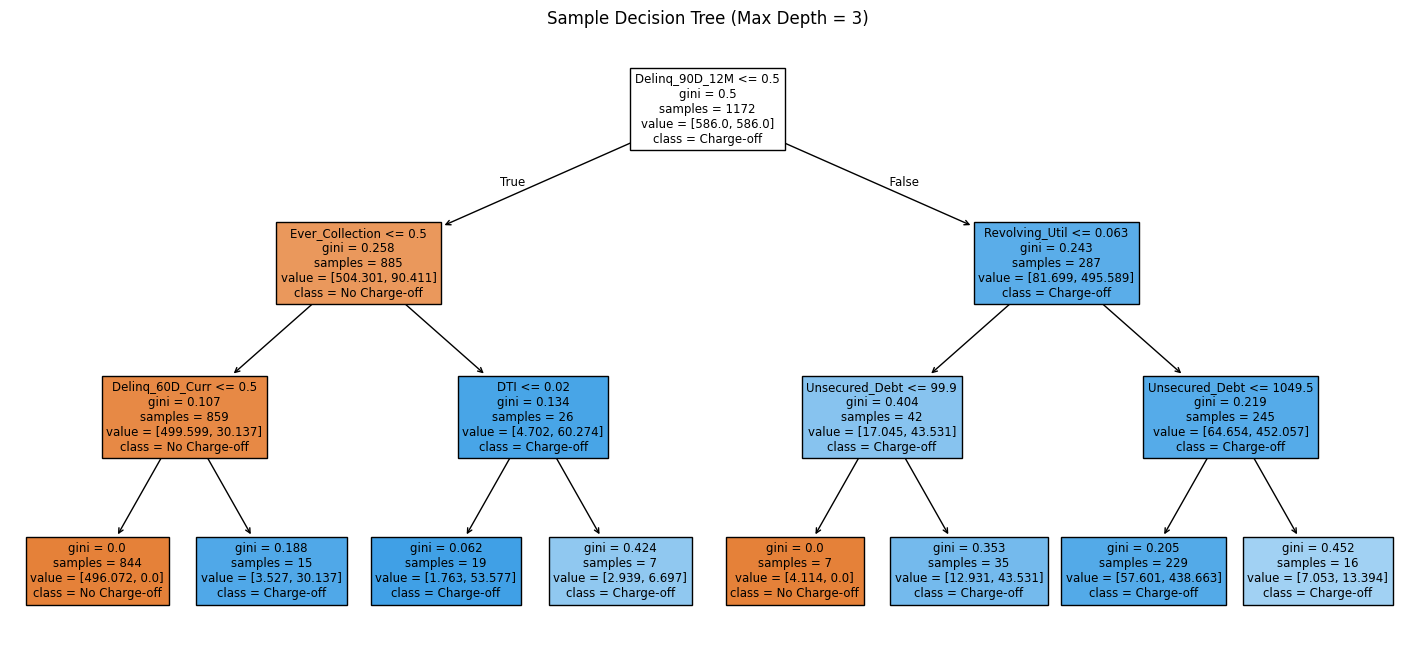

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

print('\n14. Visualizing a Sample Decision Tree (Max Depth = 3):')
print('This gives a simple visual of how the model makes decisions.')
print('Gini = 0.5 at the root means maximum uncertainty — improves as we go deeper.')

tree = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
tree.fit(X_train, y_train)

plt.figure(figsize=(18, 8))
plot_tree(tree, feature_names=X_train.columns, class_names=['No Charge-off', 'Charge-off'], filled=True)
plt.title('Sample Decision Tree (Max Depth = 3)')
plt.show()


15. Top 15 Feature Importances — Random Forest:
            Feature  Importance
     Delinq_90D_12M    0.378379
    Ever_Collection    0.184417
    Delinq_60D_Curr    0.171101
     Revolving_Util    0.035948
     Unsecured_Debt    0.032909
     Checking_Asset    0.032868
                DTI    0.029146
             Income    0.029111
       FICO_Imputed    0.021850
                Age    0.021830
   Student_Loan_Amt    0.016626
   Card_Inquiry_12M    0.010547
      Card_Open_24M    0.009657
Counseling_Last_12M    0.004302
    Delinq_30D_Curr    0.003658


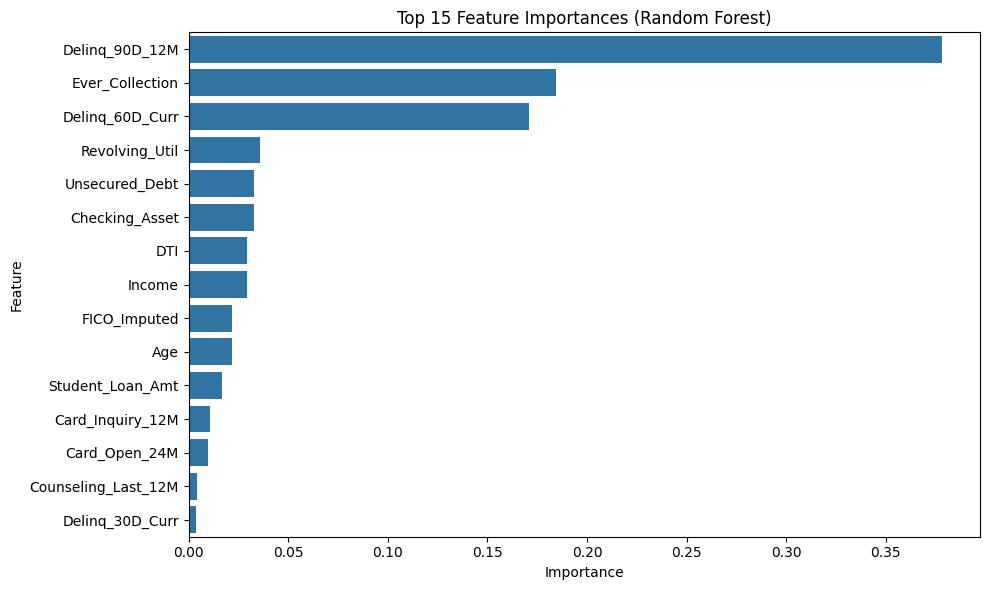

In [15]:
print('\n15. Top 15 Feature Importances — Random Forest:')

rf_feat_imp = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(rf_feat_imp.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_feat_imp.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()


=== Step 16: XGBoost — Predict Ever_ChargeOff ===
XGBoost uses boosting (sequential trees) vs Random Forest (parallel trees).
We compare both to find which model has higher AUC and Precision.

scale_pos_weight = 5.70 (ratio of non-chargeoff to chargeoff)

--- XGBoost: Validation Performance ---
[[208  13]
 [ 11  19]]
              precision    recall  f1-score   support

           0      0.950     0.941     0.945       221
           1      0.594     0.633     0.613        30

    accuracy                          0.904       251
   macro avg      0.772     0.787     0.779       251
weighted avg      0.907     0.904     0.906       251

Validation AUC: 0.953


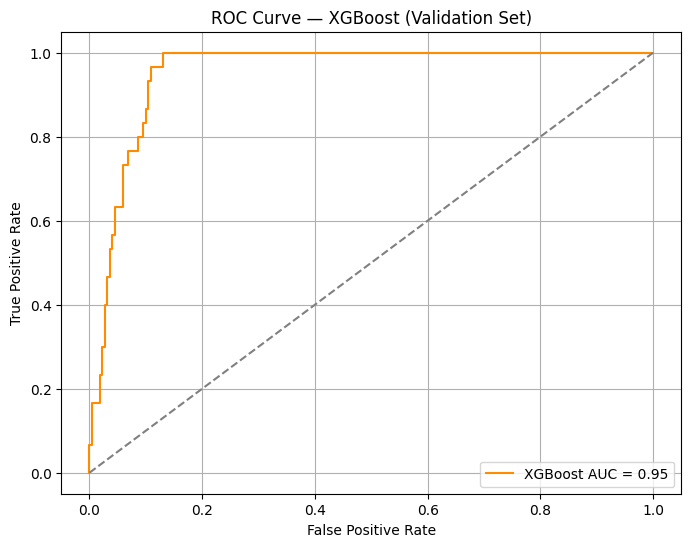


--- XGBoost: Test Set Performance ---
[[202  17]
 [ 13  20]]
              precision    recall  f1-score   support

           0      0.940     0.922     0.931       219
           1      0.541     0.606     0.571        33

    accuracy                          0.881       252
   macro avg      0.740     0.764     0.751       252
weighted avg      0.887     0.881     0.884       252

Test AUC: 0.942

As a startup expanding into NTC, we use a 0.7 threshold to prioritize Precision.
When the model flags someone as high-risk, we are highly confident.
Trade-off: lower Recall, but fewer false rejections — keeps more potential customers in the funnel.


In [16]:
from xgboost import XGBClassifier

print('\n=== Step 16: XGBoost — Predict Ever_ChargeOff ===')
print('XGBoost uses boosting (sequential trees) vs Random Forest (parallel trees).')
print('We compare both to find which model has higher AUC and Precision.')

# scale_pos_weight handles class imbalance
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
print(f'\nscale_pos_weight = {scale_pos_weight:.2f} (ratio of non-chargeoff to chargeoff)')

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

val_probs_xgb = xgb_model.predict_proba(X_val)[:, 1]
val_pred_xgb  = (val_probs_xgb >= 0.7).astype(int)
val_auc_xgb   = roc_auc_score(y_val, val_probs_xgb)

print('\n--- XGBoost: Validation Performance ---')
print(confusion_matrix(y_val, val_pred_xgb))
print(classification_report(y_val, val_pred_xgb, digits=3))
print(f'Validation AUC: {val_auc_xgb:.3f}')

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, val_probs_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost AUC = {val_auc_xgb:.2f}', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XGBoost (Validation Set)')
plt.legend()
plt.grid()
plt.show()

# Test Set
test_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
test_pred_xgb  = (test_probs_xgb >= 0.7).astype(int)

print('\n--- XGBoost: Test Set Performance ---')
print(confusion_matrix(y_test, test_pred_xgb))
print(classification_report(y_test, test_pred_xgb, digits=3))
print(f'Test AUC: {roc_auc_score(y_test, test_probs_xgb):.3f}')

print('\nAs a startup expanding into NTC, we use a 0.7 threshold to prioritize Precision.')
print('When the model flags someone as high-risk, we are highly confident.')
print('Trade-off: lower Recall, but fewer false rejections — keeps more potential customers in the funnel.')


17. Top 15 Feature Importances — XGBoost:
            Feature  Importance
     Delinq_90D_12M    0.560370
    Ever_Collection    0.140964
    Delinq_60D_Curr    0.087014
     Delinq_60D_12M    0.023375
      Personal_Loan    0.020273
    Delinq_30D_Curr    0.015544
   Card_Inquiry_12M    0.012495
     Auth_User_Only    0.012069
                Age    0.011493
      Card_Open_24M    0.011471
     Unsecured_Debt    0.011023
     Checking_Asset    0.010862
                DTI    0.010399
       FICO_Imputed    0.010018
Counseling_Last_12M    0.009522


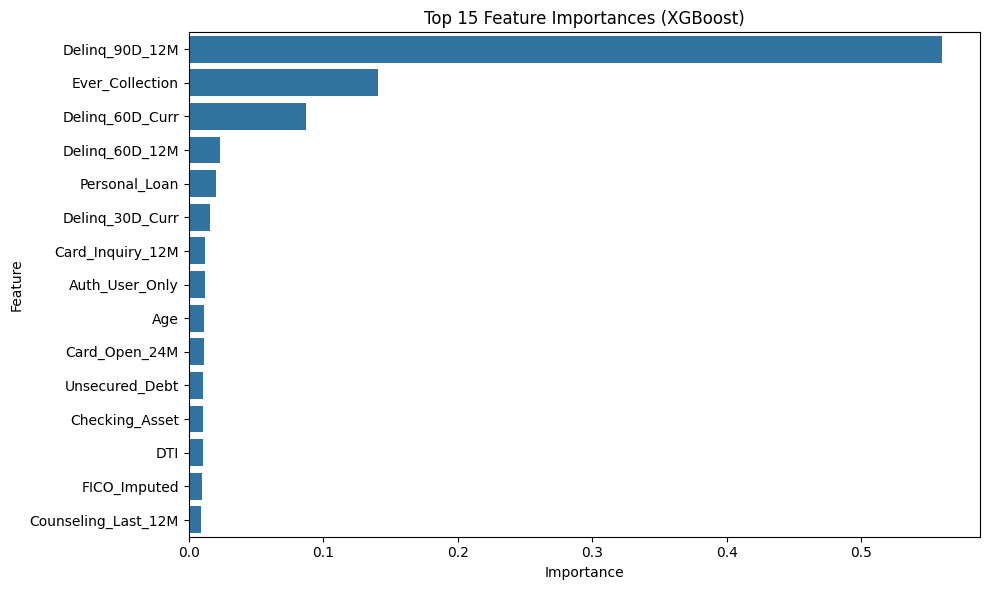

In [17]:
print('\n17. Top 15 Feature Importances — XGBoost:')

xgb_feat_imp = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(xgb_feat_imp.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_feat_imp.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()


18. Model Comparison: Random Forest vs XGBoost


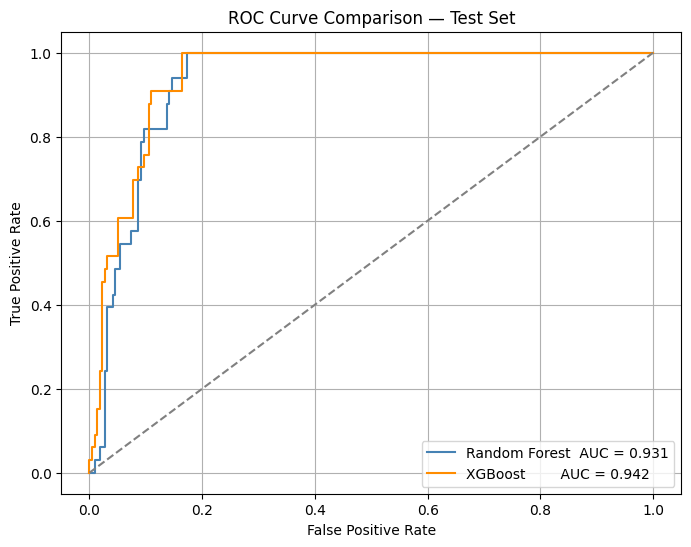


Random Forest Test AUC : 0.931
XGBoost Test AUC       : 0.942

Winner: XGBoost (higher AUC = better at distinguishing charge-off vs no charge-off)


In [18]:
print('\n18. Model Comparison: Random Forest vs XGBoost')

rf_auc  = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest  AUC = {rf_auc:.3f}',  color='steelblue')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost        AUC = {xgb_auc:.3f}', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — Test Set')
plt.legend()
plt.grid()
plt.show()

print(f'\nRandom Forest Test AUC : {rf_auc:.3f}')
print(f'XGBoost Test AUC       : {xgb_auc:.3f}')
winner = 'XGBoost' if xgb_auc > rf_auc else 'Random Forest'
print(f'\nWinner: {winner} (higher AUC = better at distinguishing charge-off vs no charge-off)')

In [19]:
print('\n19. Export Final Results to CSV')

# Add predicted probability and label from XGBoost
df_cleaned['Predicted_ChargeOff_Prob']  = xgb_model.predict_proba(df_cleaned[feature_cols])[:, 1]
df_cleaned['Predicted_ChargeOff_Label'] = (df_cleaned['Predicted_ChargeOff_Prob'] >= 0.7).astype(int)

output_path = '/content/NTC_Consumer_Credit_Output.csv'
df_cleaned.to_csv(output_path, index=False)
print(f'\nData exported successfully to {output_path}')

print('\nSample Results (First 10 Rows):')
print(df_cleaned[['No_Hit', 'Age', 'FICO_V', 'FICO_Band', 'Revolving_Util',
                  'Ever_ChargeOff', 'Predicted_ChargeOff_Prob',
                  'Predicted_ChargeOff_Label']].head(10))

# Download file to your computer
from google.colab import files
files.download(output_path)


19. Export Final Results to CSV

Data exported successfully to /content/NTC_Consumer_Credit_Output.csv

Sample Results (First 10 Rows):
    No_Hit  Age  FICO_V FICO_Band  Revolving_Util  Ever_ChargeOff  \
0        0   24   669.0      Fair        0.124821               0   
1        1   21     NaN       NaN        0.203015               0   
2        0   22   553.0      Poor        0.245630               0   
3        1   24     NaN       NaN        0.427178               0   
4        0   20   508.0      Poor        0.505691               1   
5        0   25   645.0      Fair        0.176189               0   
7        0   22   611.0      Fair        0.284398               0   
8        0   24   501.0      Poor        0.373935               0   
9        1   19     NaN       NaN        0.329203               0   
10       1   20     NaN       NaN        0.313677               0   

    Predicted_ChargeOff_Prob  Predicted_ChargeOff_Label  
0                   0.001310                 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>